# Analyse de spectres de l'hydrogène

Les données que nous allons analyser sont des données de spectroscopie de l'atome de deutérieum (l'isotope de l'hydrogène de masse atomique 2). Dans le modèle simple de Bohr, les niveaux d'énergies sont donnés par : 

$$
E_n = -hc\frac{R_D}{n^2}
$$

où $h$ et la constante de Planck, $c$ la célérité de la lumière et $R_D$ la constante de Rydberg du deutérium qui est reliée à la constante de Rydberg $R_\infty$ par : 

$$ 
R_D = \frac{R_\infty}{1+\frac{m_e}{m_D}}
$$

où $m_e$ est la masse de l'électron et $m_D$ celle du Deuteron (Noyau de l'atome de deutérium : un proton et un neutron). La constante $R_\infty$ correspond à la constante de Rydberg pour un noyau de masse infinie.

La transition que l'on étudie est la transition entre les niveau $n=1$ et $n=3$. Sa fréquence vaut : 

$$
\nu_\mathrm{Bohr} = \frac{E_3 - E_1}{h}
$$

* Constante de rydberg : $R_\infty = 10973731.56816$ m$^{-1}$
* Rapport de masse : $\frac{m_D}{m_e} = 3670.4829679$
* Vitesse de la lumière dans le vide: $c = 299792458$ m/s


1. Calculer la fréquence de la transition dans le modèle de Bohr et donner sa valeur en MHz. On formatera la valeur pour avoir trois chiffres après la virgule (précision au kHz).

In [1]:
import numpy as np
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt

In [2]:
R_infty = 10973731.56816
mD_sur_me = 3670.4829679
me_sur_mD = 1/mD_sur_me
c = 299792458

RD = R_infty/(1+me_sur_mD)

freq_transition_bohr = RD*(1 - 1/9)*c
print(f'Nu Bohr : {freq_transition_bohr/1E6:.3f} MHz')

Nu Bohr : 2923507473.443 MHz


Le principe de la spectroscopie consiste a illuminer un jet d'atomes à l'aide d'un laser dont on connait la fréquence et à mesurer la fluorescence des atomes. Cette fluorescence étant très faible, on utilise un compteur de photon pour la mesurer.

Les données sont dans le fichier {download}`data/data_hydrogene_simple.txt`. Il s'agit d'un fichier texte simple. Il comprend une colonne qui correspond à la fréquence (mesurée) du laser de spectroscopie en MHz et une colonne qui correspond au nombre de photons détectés sur une seconde de mesure. Ce nombre est proportionnel au nombre de photons absorbés par les atomes d'hydrogènes.  

2. Lire et afficher les données.

In [3]:
freq, counts = np.loadtxt('data/data_hydrogene_simple.txt', unpack=True)

Text(0, 0.5, 'Counts [/s]')

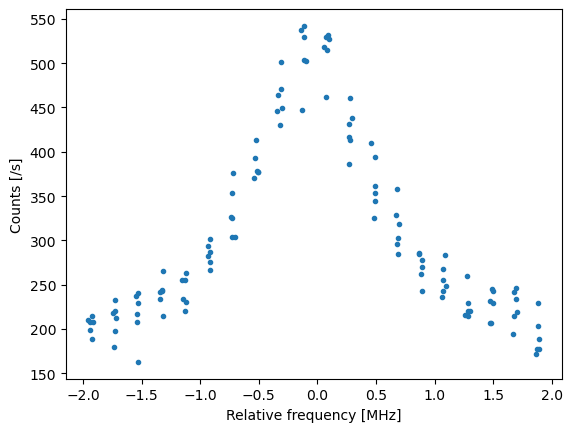

In [4]:
fig = figure()
ax = fig.subplots(1, 1)

ax.plot(freq, counts, '.')
ax.set_xlabel('Relative frequency [MHz]')
ax.set_ylabel('Counts [/s]')

On va ajuster le profile par une fonction lorentzienne : 

$$ 
a + \frac{b}{1+ \left(\frac{f-f_0}{\Delta f}\right)^2}
$$

où $a$ est un offset, $b$ une amplitude, $f_0$ la fréquence centrale et $\Delta f$ la largeur en fréquence. 

3. Faire un ajustement des données par une lorentzienne (que l'on représentera graphiquement).

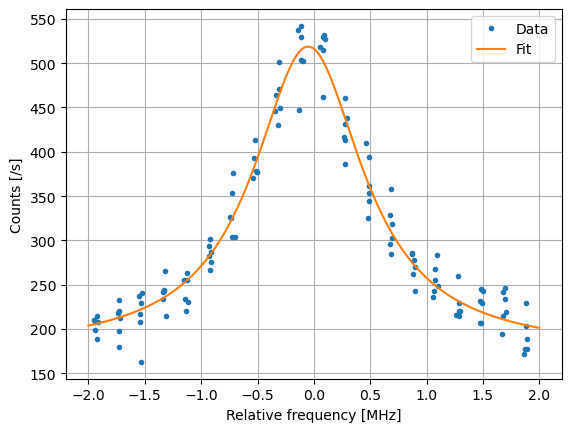

In [5]:
from scipy.optimize import curve_fit

def fonction(x, offset, amplitude, centre, largeur):
    return offset + amplitude/(1 + ((x-centre)/largeur)**2)

p0 = 100, 300, 0, 1
popt, pcov = curve_fit(fonction, freq, counts, p0)

x = np.linspace(-2, 2, 201)
fig = figure()
ax = fig.subplots(1, 1)

ax.plot(freq, counts, '.', label='Data')
ax.plot(x, fonction(x, *popt),label='Fit')
ax.set_xlabel('Relative frequency [MHz]')
ax.set_ylabel('Counts [/s]')
ax.legend()
ax.grid()

Les données sont prises par rapport à une fréquence de référence, c'est à dire que la fréquence du laser est la somme entre la fréquence de référence ($f_\mathrm{ref} = 2923538429.3$ MHz) et la fréquence des données. 

4. Donner la valeur de la fréquence absolue $\nu$ ainsi que l'incertitude absolue $\sigma_\nu$ et relative $\sigma \nu / \nu$) de la mesure du pic. La différence par rapport à la valeur du modèle de Bohr est dûe a des corrections supplémentaires (effet du spin de l'électron, de la taille fini du noyau, effets relativistes, ou encore de la polarization du vide qui peuvent être calculés à l'aide de l'Electrodynamique Quantique). Calculer cet écart.

In [6]:
freq_ref = 2923538429.3

freq_abs = freq_ref + popt[2]
sigma_abs = np.sqrt(pcov[2, 2])

print(f'Frequence : {freq_abs} MHz')
print(f'Incertitude : {sigma_abs*1e3:.2f} kHz')
print(f'Incertitude relative : {sigma_abs/freq_abs:.2e}')
print(f'Différence avec la valeur du modèle : {freq_transition_bohr*1e-6-freq_abs:.1f} MHz')

Frequence : 2923538429.2486176 MHz
Incertitude : 10.23 kHz
Incertitude relative : 3.50e-12
Différence avec la valeur du modèle : -30955.8 MHz
